# 特征值与特征向量  
想象一个线性变换 A作用在二维平面上——它可能是拉伸、旋转、剪切的组合。**大多数向量经过变换后方向都会改变**，但有一类特殊的向量，变换后**只是被拉长或缩短，方向保持不变（或反向）**，这就是**特征向量（eigenvector）**；而对应的拉长/缩短倍数就是**特征值（eigenvalue）**。

In [2]:
import numpy as np

np.random.seed(42)

A = np.random.randn(2,2)
print('A=\n',A)

# 计算特征值和右特征向量
# eig 返回: eigenvalues (λ), eigenvectors (每一列是一个特征向量)
eigvals, eigvecs = np.linalg.eig(A)
print("\n特征值 λ =", eigvals)
print("特征向量矩阵 (每一列是一个特征向量):\n", eigvecs)

#验证 A v ≈ λ v
print('\n---验证 A v ≈ λ v---')
for i in range(A.shape[0]):  
    v = eigvecs[:, i]          # 第 i 个特征向量
    lam = eigvals[i]           # 对应的特征值
    lhs = A @ v                # 左边: A v
    rhs = lam * v              # 右边: λ v
    error = np.linalg.norm(lhs - rhs)
    print(f"特征对 {i}: λ={lam:.4f}")
    print(f"  A·v = {lhs}")
    print(f"  λ·v = {rhs}")
    print(f"  误差 ||Av - λv|| = {error:.2e}  (≈0 说明成立)\n")

A=
 [[ 0.49671415 -0.1382643 ]
 [ 0.64768854  1.52302986]]

特征值 λ = [0.59300419 1.42673982]
特征向量矩阵 (每一列是一个特征向量):
 [[-0.82060969  0.14705101]
 [ 0.57148905 -0.98912891]]

---验证 A v ≈ λ v---
特征对 0: λ=0.5930
  A·v = [-0.48662498  0.3388954 ]
  λ·v = [-0.48662498  0.3388954 ]
  误差 ||Av - λv|| = 5.55e-17  (≈0 说明成立)

特征对 1: λ=1.4267
  A·v = [ 0.20980354 -1.4112296 ]
  λ·v = [ 0.20980354 -1.4112296 ]
  误差 ||Av - λv|| = 2.24e-16  (≈0 说明成立)



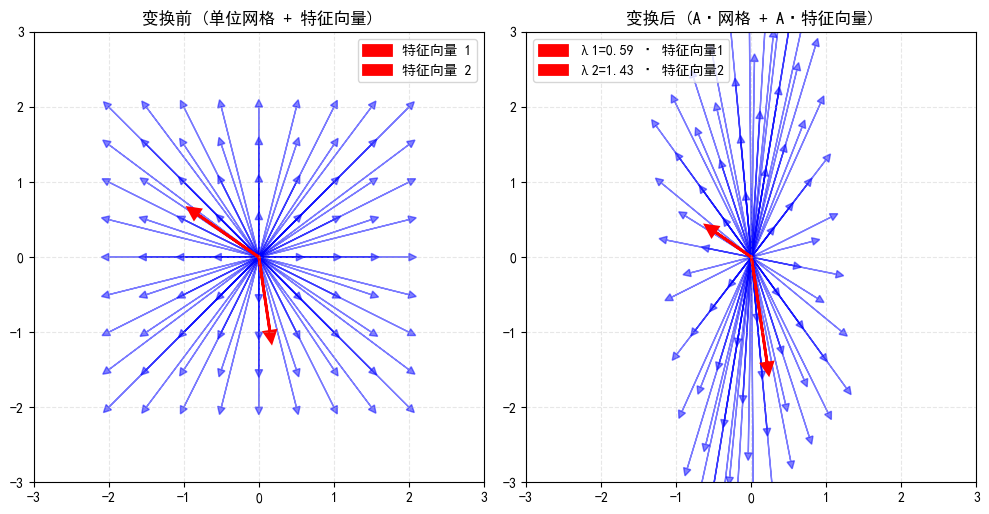

In [4]:
import matplotlib.pyplot as plt

#设置字体为黑体（Windows常用）或微软雅黑，以便支持中文显示
plt.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei']
#解决保存图像时负号'-'显示为方块的问题
plt.rcParams['axes.unicode_minus'] = False


#可视化：向量网格经 A 变换前后，并标出特征向量方向
def plot_transformation(A, eigvecs, eigvals):
    fig, axes = plt.subplots(1, 2, figsize=(10, 5))
    
    # 生成网格向量
    x = np.linspace(-2, 2, 9)
    y = np.linspace(-2, 2, 9)
    XX, YY = np.meshgrid(x, y)
    vectors = np.array([XX.flatten(), YY.flatten()])
    
    # 左图：变换前
    ax = axes[0]
    for i in range(vectors.shape[1]):
        ax.arrow(0, 0, vectors[0, i], vectors[1, i],
                 head_width=0.1, head_length=0.1,
                 fc='blue', ec='blue', alpha=0.5)
    for i in range(eigvecs.shape[1]):
        v = eigvecs[:, i]
        ax.arrow(0, 0, v[0], v[1], head_width=0.15, head_length=0.15,
                 fc='red', ec='red', linewidth=2, label=f'特征向量 {i+1}')
    ax.set_title("变换前 (单位网格 + 特征向量)")
    ax.set_xlim(-3, 3); ax.set_ylim(-3, 3)
    ax.grid(True, linestyle='--', alpha=0.3)
    ax.legend()
    ax.set_aspect('equal')
    
    # 右图：变换后 (A @ 向量)
    ax = axes[1]
    transformed = A @ vectors
    for i in range(transformed.shape[1]):
        ax.arrow(0, 0, transformed[0, i], transformed[1, i],
                 head_width=0.1, head_length=0.1,
                 fc='blue', ec='blue', alpha=0.5)
    # 特征向量方向在变换后应保持不变 (只被 λ 缩放)
    for i in range(eigvecs.shape[1]):
        v = eigvecs[:, i]
        scaled_v = A @ v   # 等于 λ v
        ax.arrow(0, 0, scaled_v[0], scaled_v[1], head_width=0.15,
                 head_length=0.15, fc='red', ec='red', linewidth=2,
                 label=f'λ{i+1}={eigvals[i]:.2f} · 特征向量{i+1}')
    ax.set_title("变换后 (A·网格 + A·特征向量)")
    ax.set_xlim(-3, 3); ax.set_ylim(-3, 3)
    ax.grid(True, linestyle='--', alpha=0.3)
    ax.legend()
    ax.set_aspect('equal')
    
    plt.tight_layout()
    plt.show()

plot_transformation(A, eigvecs, eigvals)

### 注意  
-  **特征向量不唯一**  
    特征向量表示的是一条过原点的直线方向，而非特定向量
    在 np.linalg.eig的输出中，特征向量被归一化为单位长度，但仍有两个可能方向（±） 

-  **特征值可能为复数   
    当矩阵有**旋转**成分，即使A是实矩阵，特征值也可能是复数  
    复数特征值总是共轭成对出现  
    对称矩阵（实数对称）的特征值一定是实数——这是 PCA 能用特征值分解的理论基础  

-  **特征向量的正交性  
    一般矩阵：特征向量不一定正交，甚至可能不是线性无关的
    对称矩阵：不同特征值对应的特征向量相互**正交**  
    
-  **亏损矩阵（Defective Matrix）**  
    理论上 n×n矩阵应有 n个特征值（计入重数），但特征向量可能不足 n个线性无关的 → 这种矩阵叫亏损矩阵  
        例：[1 1]只有一个特征值 λ=1，几何重数为 1（只有一个线性无关的特征向量）
            0 1  
    亏损矩阵无法对角化，只能用 Jordan 标准形  

-  **代数重数 vs 几何重数**
    代数重数：特征值作为特征方程的根的重数  
    几何重数：该特征值对应的线性无关特征向量的个数  
    恒有：几何重数 ≤ 代数重数  
    当且仅当对所有特征值等号成立时，矩阵可对角化  

-  **数值计算的注意事项**  
    eig用于一般矩阵，可能返回复数结果  
    eigh专门用于对称/Hermitian 矩阵，数值更稳定，且保证实特征值


    

In [ ]:
# np.linalg.eig 对一般矩阵
eigvals, eigvecs = np.linalg.eig(A)

# 对对称矩阵，应使用更稳定的版本
eigvals, eigvecs = np.linalg.eigh(A)  # 'h' 代表 Hermitian

- **特征值的绝对值含义**  
    |λi|>1:该方向放大  
    |λi|<1:该方向收缩  
    最大|λi|称为**谱半径**，决定迭代 Akv的长期行为  
    在动力系统中，若所有|λi|<1,系统是稳定的  